<a href="https://colab.research.google.com/github/garrick-watkins/netflix-ab-testing/blob/main/MIS432_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Step 3
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# --- Experiment Configuration ---
n_users = 1000
click_prob = {"A": 0.24, "B": 0.30}

# --- Step 1: Assign users to artwork variants ---
user_ids = np.arange(1, n_users + 1)
assignments = np.random.choice(["A", "B"], size=n_users, p=[0.5, 0.5])

# --- Step 2: Simulate clicks based on variant probability ---
clicks = np.array([
    np.random.binomial(1, click_prob[variant])
    for variant in assignments
])

# --- Step 3: Build the results DataFrame ---
df = pd.DataFrame({
    "user_id":  user_ids,
    "artwork":  assignments,
    "clicked":  clicks
})

# --- Step 4: Quick summary ---
print("=== Experiment Results ===\n")
print(df.head(10).to_string(index=False))
print(f"\nTotal users: {len(df)}")
summary = df.groupby("artwork")["clicked"].agg(
    users="count",
    clicks="sum",
    click_rate=lambda x: round(x.mean(), 4)
)
print(f"\n{summary}")

       A/B Test — Summary Results

Artwork       Users   Clicks      CTR
--------------------------------------
  A             503      127   25.25%
  B             497      154   30.99%

  Absolute lift (B over A): 5.74 percentage points


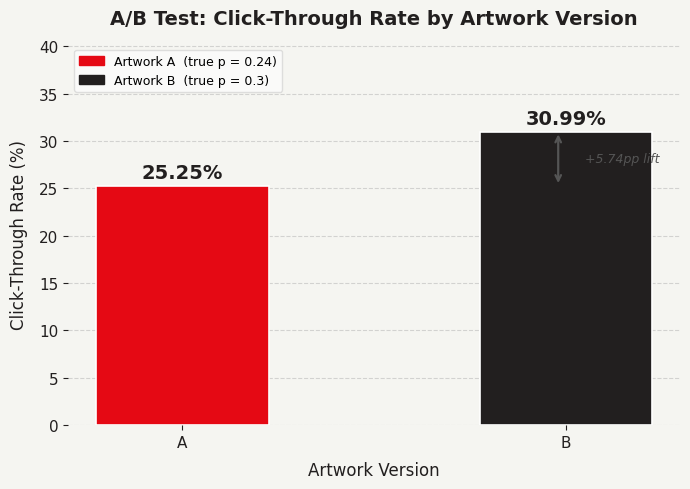


Chart saved as ab_test_ctr.png


In [ ]:
#Step 4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Experiment Configuration ──────────────────────────────────────────────────
np.random.seed(42)
n_users    = 1000
click_prob = {"A": 0.24, "B": 0.30}

# ── Step 1: Assign users to artwork variants ──────────────────────────────────
user_ids    = np.arange(1, n_users + 1)
assignments = np.random.choice(["A", "B"], size=n_users, p=[0.5, 0.5])

# ── Step 2: Simulate clicks based on variant probability ──────────────────────
clicks = np.array([
    np.random.binomial(1, click_prob[variant])
    for variant in assignments
])

# ── Step 3: Build the results DataFrame ──────────────────────────────────────
df = pd.DataFrame({
    "user_id" : user_ids,
    "artwork"  : assignments,
    "clicked"  : clicks
})

# ── Step 4: Summary metrics per group ────────────────────────────────────────
summary = (
    df.groupby("artwork")["clicked"]
    .agg(
        total_users  = "count",
        total_clicks = "sum",
        ctr          = "mean"
    )
    .reset_index()
)
summary["ctr_pct"] = (summary["ctr"] * 100).round(2)

print("=" * 45)
print("       A/B Test — Summary Results")
print("=" * 45)
print(f"\n{'Artwork':<10} {'Users':>8} {'Clicks':>8} {'CTR':>8}")
print("-" * 38)
for _, row in summary.iterrows():
    print(f"  {row['artwork']:<8} {int(row['total_users']):>8} "
          f"{int(row['total_clicks']):>8} {row['ctr_pct']:>7}%")

lift = summary.loc[summary["artwork"] == "B", "ctr"].values[0] \
     - summary.loc[summary["artwork"] == "A", "ctr"].values[0]
print(f"\n  Absolute lift (B over A): {lift*100:.2f} percentage points")
print("=" * 45)

# ── Step 5: Bar chart ─────────────────────────────────────────────────────────
COLORS     = {"A": "#E50914", "B": "#221F1F"}   # Netflix red / near-black
BACKGROUND = "#F5F5F1"                           # warm off-white canvas

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

artworks   = summary["artwork"].tolist()
ctrs       = summary["ctr_pct"].tolist()
bar_colors = [COLORS[a] for a in artworks]

bars = ax.bar(artworks, ctrs, color=bar_colors, width=0.45,
              edgecolor="white", linewidth=1.2, zorder=3)

# Value labels on bars
for bar, val in zip(bars, ctrs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{val}%",
        ha="center", va="bottom",
        fontsize=14, fontweight="bold", color="#221F1F"
    )

# Lift annotation arrow
y_a   = ctrs[0]
y_b   = ctrs[1]
x_mid = 0.98
ax.annotate(
    "", xy=(x_mid, y_b), xytext=(x_mid, y_a),
    arrowprops=dict(arrowstyle="<->", color="#555555", lw=1.6)
)
ax.text(
    x_mid + 0.07, (y_a + y_b) / 2,
    f"+{lift*100:.2f}pp lift",
    va="center", fontsize=9, color="#555555", style="italic"
)

# Grid & axes
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, max(ctrs) * 1.3)
ax.set_xlabel("Artwork Version", fontsize=12, labelpad=8, color="#221F1F")
ax.set_ylabel("Click-Through Rate (%)", fontsize=12, labelpad=8, color="#221F1F")
ax.set_title("A/B Test: Click-Through Rate by Artwork Version",
             fontsize=14, fontweight="bold", pad=14, color="#221F1F")
ax.tick_params(colors="#221F1F", labelsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend
legend_patches = [
    mpatches.Patch(color=COLORS["A"], label=f"Artwork A  (true p = {click_prob['A']})"),
    mpatches.Patch(color=COLORS["B"], label=f"Artwork B  (true p = {click_prob['B']})")
]
ax.legend(handles=legend_patches, fontsize=9,
          framealpha=0.6, loc="upper left")

plt.tight_layout()
plt.savefig("ab_test_ctr.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as ab_test_ctr.png")

        A/B Test — Summary Results

Artwork       Users   Clicks      CTR
----------------------------------------
  A             503      127   25.25%
  B             497      154   30.99%

  Absolute lift (B over A): 5.74 percentage points

        Statistical Test Results

  Test              : Two-Proportion Z-Test
  Z-Score           : 2.0182
  P-Value           : 0.0436
  Significance Level: 0.05
  95% CI on Lift    : [0.17pp,  11.31pp]

  Verdict: ✅ SIGNIFICANT — Artwork B wins.


/tmp/ipykernel_17511/1670430718.py:162: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17511/1670430718.py:163: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("ab_test_ctr_with_stats.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


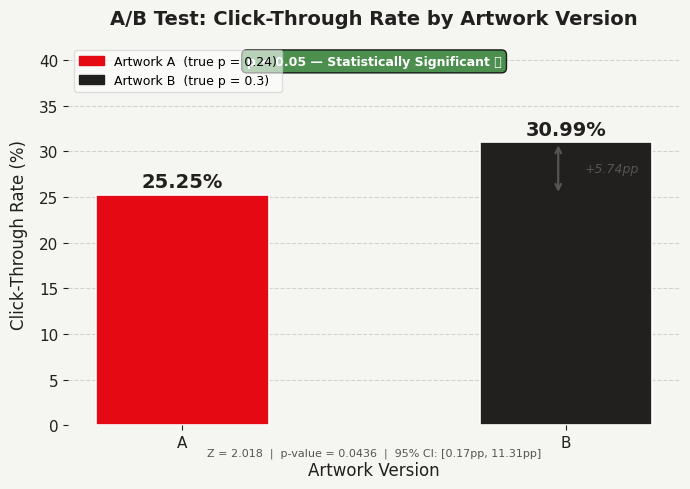


Chart saved as ab_test_ctr_with_stats.png


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# ── Experiment Configuration ──────────────────────────────────────────────────
np.random.seed(42)
n_users    = 1000
click_prob = {"A": 0.24, "B": 0.30}

# ── Step 1: Assign users to artwork variants ──────────────────────────────────
user_ids    = np.arange(1, n_users + 1)
assignments = np.random.choice(["A", "B"], size=n_users, p=[0.5, 0.5])

# ── Step 2: Simulate clicks based on variant probability ──────────────────────
clicks = np.array([
    np.random.binomial(1, click_prob[variant])
    for variant in assignments
])

# ── Step 3: Build the results DataFrame ──────────────────────────────────────
df = pd.DataFrame({
    "user_id" : user_ids,
    "artwork"  : assignments,
    "clicked"  : clicks
})

# ── Step 4: Summary metrics per group ────────────────────────────────────────
summary = (
    df.groupby("artwork")["clicked"]
    .agg(
        total_users  = "count",
        total_clicks = "sum",
        ctr          = "mean"
    )
    .reset_index()
)
summary["ctr_pct"] = (summary["ctr"] * 100).round(2)

n_a      = int(summary.loc[summary["artwork"] == "A", "total_users"].values[0])
n_b      = int(summary.loc[summary["artwork"] == "B", "total_users"].values[0])
clicks_a = int(summary.loc[summary["artwork"] == "A", "total_clicks"].values[0])
clicks_b = int(summary.loc[summary["artwork"] == "B", "total_clicks"].values[0])
ctr_a    = summary.loc[summary["artwork"] == "A", "ctr"].values[0]
ctr_b    = summary.loc[summary["artwork"] == "B", "ctr"].values[0]
lift     = ctr_b - ctr_a

print("=" * 48)
print("        A/B Test — Summary Results")
print("=" * 48)
print(f"\n{'Artwork':<10} {'Users':>8} {'Clicks':>8} {'CTR':>8}")
print("-" * 40)
for _, row in summary.iterrows():
    print(f"  {row['artwork']:<8} {int(row['total_users']):>8} "
          f"{int(row['total_clicks']):>8} {row['ctr_pct']:>7}%")
print(f"\n  Absolute lift (B over A): {lift*100:.2f} percentage points")
print("=" * 48)

# ── Step 5: Two-Proportion Z-Test ─────────────────────────────────────────────
#  Build a 2x2 contingency table:
#               Clicked   Did Not Click
#  Artwork A  [ clicks_a,  n_a - clicks_a ]
#  Artwork B  [ clicks_b,  n_b - clicks_b ]

contingency_table = np.array([
    [clicks_a, n_a - clicks_a],
    [clicks_b, n_b - clicks_b]
])

chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table, correction=False
)

# Derive the z-score and 95% confidence interval for the lift
z_score = np.sqrt(chi2) * np.sign(ctr_b - ctr_a)

pooled_p = (clicks_a + clicks_b) / (n_a + n_b)
se       = np.sqrt(pooled_p * (1 - pooled_p) * (1/n_a + 1/n_b))
z_crit   = 1.96                                  # 95% confidence, two-tailed
ci_lower = lift - z_crit * se
ci_upper = lift + z_crit * se

ALPHA = 0.05
significant = p_value < ALPHA

print("\n" + "=" * 48)
print("        Statistical Test Results")
print("=" * 48)
print(f"\n  Test              : Two-Proportion Z-Test")
print(f"  Z-Score           : {z_score:.4f}")
print(f"  P-Value           : {p_value:.4f}")
print(f"  Significance Level: {ALPHA}")
print(f"  95% CI on Lift    : [{ci_lower*100:.2f}pp,  {ci_upper*100:.2f}pp]")
print(f"\n  Verdict: {'✅ SIGNIFICANT — Artwork B wins.' if significant else '❌ NOT significant — cannot declare a winner.'}")
print("=" * 48)

# ── Step 6: Bar chart with significance badge ─────────────────────────────────
COLORS     = {"A": "#E50914", "B": "#221F1F"}
BACKGROUND = "#F5F5F1"

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

artworks   = summary["artwork"].tolist()
ctrs       = summary["ctr_pct"].tolist()
bar_colors = [COLORS[a] for a in artworks]

bars = ax.bar(artworks, ctrs, color=bar_colors, width=0.45,
              edgecolor="white", linewidth=1.2, zorder=3)

for bar, val in zip(bars, ctrs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{val}%",
        ha="center", va="bottom",
        fontsize=14, fontweight="bold", color="#221F1F"
    )

# Lift arrow
x_mid = 0.98
ax.annotate("", xy=(x_mid, ctrs[1]), xytext=(x_mid, ctrs[0]),
            arrowprops=dict(arrowstyle="<->", color="#555555", lw=1.6))
ax.text(x_mid + 0.07, (ctrs[0] + ctrs[1]) / 2,
        f"+{lift*100:.2f}pp", va="center",
        fontsize=9, color="#555555", style="italic")

# Significance badge
badge_text  = "p < 0.05 — Statistically Significant ✅" if significant \
              else "p ≥ 0.05 — Not Significant ❌"
badge_color = "#2E7D32" if significant else "#B71C1C"
ax.text(0.5, 0.97, badge_text,
        transform=ax.transAxes, ha="center", va="top",
        fontsize=9, color="white", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=badge_color, alpha=0.85))

# p-value subtitle
ax.text(0.5, -0.08,
        f"Z = {z_score:.3f}  |  p-value = {p_value:.4f}  |  "
        f"95% CI: [{ci_lower*100:.2f}pp, {ci_upper*100:.2f}pp]",
        transform=ax.transAxes, ha="center", fontsize=8, color="#555555")

ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(0, max(ctrs) * 1.35)
ax.set_xlabel("Artwork Version", fontsize=12, labelpad=8, color="#221F1F")
ax.set_ylabel("Click-Through Rate (%)", fontsize=12, labelpad=8, color="#221F1F")
ax.set_title("A/B Test: Click-Through Rate by Artwork Version",
             fontsize=14, fontweight="bold", pad=14, color="#221F1F")
ax.tick_params(colors="#221F1F", labelsize=11)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(color=COLORS["A"], label=f"Artwork A  (true p = {click_prob['A']})"),
    mpatches.Patch(color=COLORS["B"], label=f"Artwork B  (true p = {click_prob['B']})")
]
ax.legend(handles=legend_patches, fontsize=9, framealpha=0.6, loc="upper left")

plt.tight_layout()
plt.savefig("ab_test_ctr_with_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as ab_test_ctr_with_stats.png")